A deep learning model for classifying **11 dog breeds** from images, achieving **95% accuracy on the test set**.

## Approach
- **Architecture**: DenseNet201 pretrained on ImageNet, used as a frozen feature extractor
- **Head**: Custom Conv2D → GlobalAveragePooling → Dense(128, ReLU) → Dense(11, Softmax)
- **Framework**: TensorFlow / Keras
- **Dataset**: 11-class dog breed dataset with train/test split

## Pipeline
1. Custom data generator with DenseNet-specific preprocessing
2. Transfer learning with frozen base model
3. Trained classification head on domain-specific data

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
path = "/mnt/c/Users/User/Downloads/dataset_dogs/dogs"
os.listdir(path)

['test', 'train']

In [8]:
def read_data(path):
    classes = {}
    labels, img_paths = [], []

    for i, dog in enumerate(sorted(os.listdir(path))):
        if dog.endswith('.json'):
            continue
        dog_breed_path = os.path.join(path, dog)
        classes[i] = dog
        for img_name in tqdm(os.listdir(dog_breed_path)):
            img_path = os.path.join(dog_breed_path, img_name)
            img_paths.append(img_path)
            labels.append(i)
            
    return classes, labels, img_paths

In [9]:
classes, labels_train, img_paths_train = read_data(os.path.join(path,'train'))
classes, labels_test, img_paths_test = read_data(os.path.join(path,'test'))

100%|███████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 287404.13it/s]


In [10]:
classes

{0: 'Afghan_hound',
 1: 'Blenheim_spaniel',
 2: 'Chihuahua',
 3: 'Japanese_spaniel',
 4: 'Maltese_dog',
 5: 'Pekinese',
 6: 'Rhodesian_ridgeback',
 7: 'Shih_Tzu',
 9: 'papillon',
 10: 'toy_terrier'}

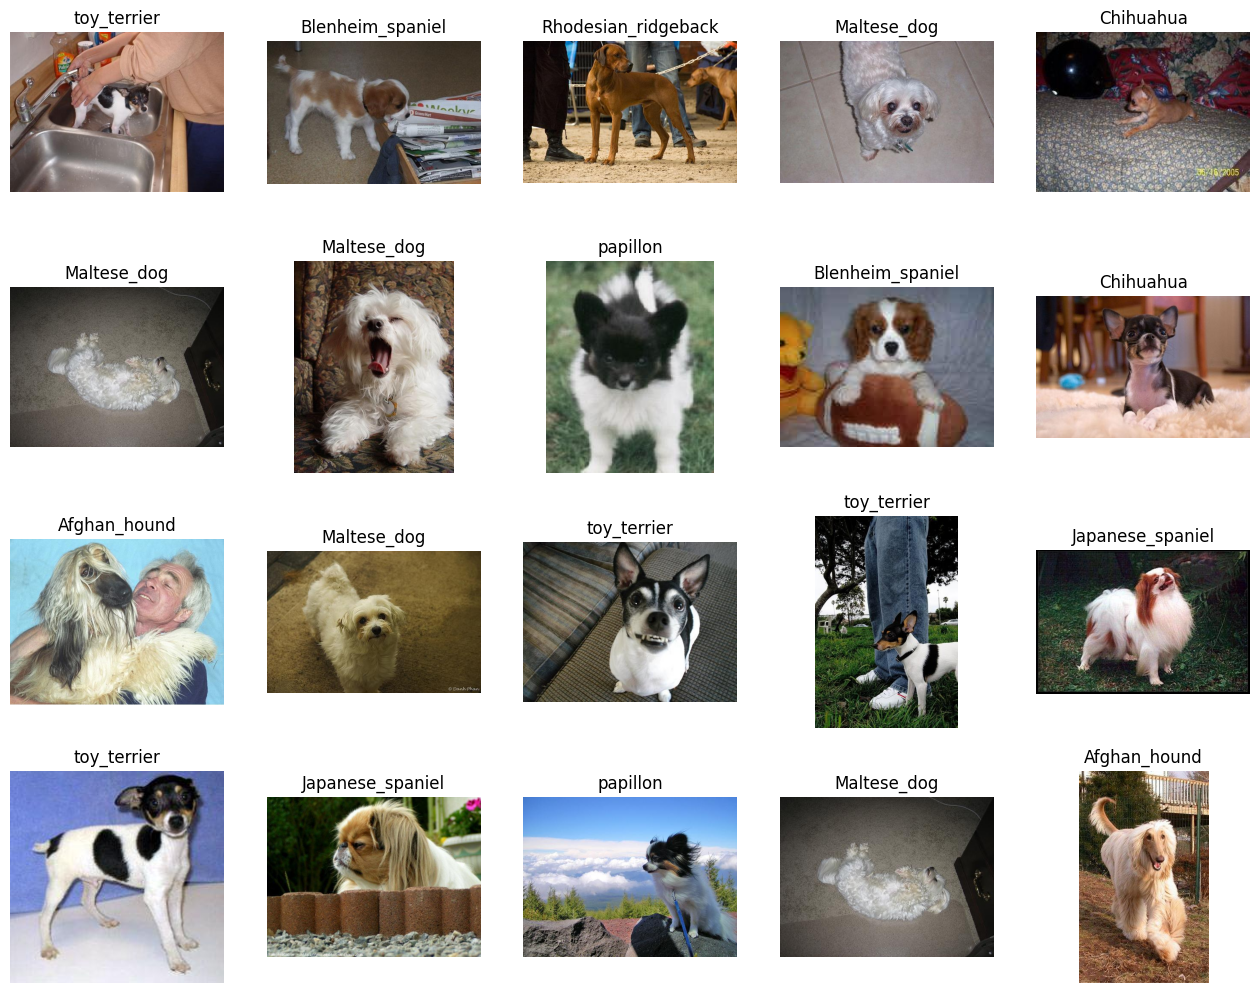

In [18]:
plt.figure(figsize = (16,16))
for i in range(20):
    ind = np.random.randint(len(img_paths_train))
    plt.subplot(5,5,i+1)
    plt.imshow(Image.open(img_paths_train[ind]))
    plt.title(classes[labels_train[ind]])
    plt.axis('off')

In [19]:
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input

In [25]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [21]:
class MyDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size = 15, target_size = (224, 224), one_hot = False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.one_hot = one_hot
    def __len__(self):
        return int(np.ceil(len(self.image_paths)/self.batch_size))

    def __getitem__(self, index):
        batch_paths = self.image_paths[index*self.batch_size: (index+1)*self.batch_size]
        batch_labels = self.labels[index*self.batch_size: (index+1)*self.batch_size]

        X = np.zeros((len(batch_paths), *self.target_size, 3), dtype = 'float32')
        y = np.array(batch_labels)

        for i,path in enumerate(batch_paths):
            img = load_img(path, target_size = self.target_size, interpolation = 'bilinear')
            X[i] = tf.keras.applications.densenet.preprocess_input(img_to_array(img))
        if self.one_hot:
            y = tf.keras.utils.to_categorical(y, num_classes = 90)
        return X, y

In [22]:
train = MyDataGenerator(img_paths_train, labels_train)
test = MyDataGenerator(img_paths_test, labels_test)

In [46]:
a = train[0][0]
a

array([[[[ 1.5125438 ,  1.8508403 ,  2.2391288 ],
         [ 1.5810429 ,  1.9208683 ,  2.3088455 ],
         [ 1.6324171 ,  1.9733893 ,  2.3611329 ],
         ...,
         [-0.5424266 , -0.05742295,  0.21734212],
         [-0.49105233, -0.00490195,  0.2696297 ],
         [-0.43967807,  0.04761905,  0.32191727]],

        [[ 1.2385478 ,  1.5707283 ,  1.9602616 ],
         [ 1.2042983 ,  1.5357143 ,  1.9254032 ],
         [ 1.1700488 ,  1.5007002 ,  1.8905448 ],
         ...,
         [-0.14855729,  0.29271722,  0.68793046],
         [-0.09718303,  0.3627452 ,  0.7576472 ],
         [-0.02868402,  0.41526622,  0.827364  ]],

        [[ 0.9988013 ,  1.3256303 ,  1.7162529 ],
         [ 0.94742703,  1.2731093 ,  1.6465361 ],
         [ 0.878928  ,  1.2030813 ,  1.5942485 ],
         ...,
         [-0.06293353,  0.3627452 ,  0.8099348 ],
         [-0.06293353,  0.3627452 ,  0.827364  ],
         [-0.09718303,  0.3452382 ,  0.7925056 ]],

        ...,

        [[-0.2855553 ,  0.57282925, -0

In [30]:
model = DenseNet201(include_top = False, input_shape=a.shape[1:])
for layer in model.layers:
    layer.trainable = False
model.summary()

Model: "densenet201"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,321,984 (69.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,321,984 (69.89 MB)

In [31]:
from tensorflow.keras.layers import Input, BatchNormalization, Conv2D, Dense, GlobalAveragePooling2D

In [42]:
inp = Input(shape = a.shape[1:])
nn = model(inp)
c = Conv2D(filters = 128,kernel_size=3)(nn)
g = GlobalAveragePooling2D()(c)
d1 = Dense(units = 128, activation = 'relu')(g)
out = Dense(units = 11, activation = 'softmax')(d1)
model_final = tf.keras.Model(inp,out)

In [43]:
classes

{0: 'Afghan_hound',
 1: 'Blenheim_spaniel',
 2: 'Chihuahua',
 3: 'Japanese_spaniel',
 4: 'Maltese_dog',
 5: 'Pekinese',
 6: 'Rhodesian_ridgeback',
 7: 'Shih_Tzu',
 9: 'papillon',
 10: 'toy_terrier'}

In [44]:
model_final.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
model_final.fit(train, epochs = 3, validation_data = test)

Epoch 1/3
107/107 ━━━━━━━━━━━━━━━━━━━━ 124s 994ms/step - accuracy: 0.5268 - loss: 5.9847 - val_accuracy: 0.6814 - val_loss: 2.5745
Epoch 2/3
107/107 ━━━━━━━━━━━━━━━━━━━━ 99s 920ms/step - accuracy: 0.8452 - loss: 1.7066 - val_accuracy: 0.8486 - val_loss: 1.1635
Epoch 3/3
107/107 ━━━━━━━━━━━━━━━━━━━━ 98s 919ms/step - accuracy: 0.9338 - loss: 0.4331 - val_accuracy: 0.9464 - val_loss: 0.3295


In [45]:
def make_prediction(path, is_web_link = True, k = 5):
    if is_web_link:
        img = Image.open(urllib.request.urlopen(path)).resize((224, 224))
    else:
        img = Image.open(path).resize((224,224))  
    plt.imshow(img)

    img = tf.keras.applications.densenet.preprocess_input(np.expand_dims(img_to_array(img), axis = 0))
    plt.axis('off')
    pred = model_final.predict(img)
    plt.title(f'Prediction - {classes[np.argmax(pred)]}')
    prob = np.sort(pred[0])[::-1]
    c = np.argsort(pred[0])[::-1]
    for i in range(k):
        print(f'{classes[c[i]]} - {prob[i]*100:.2f}%')

In [49]:
import urllib

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
papillon - 98.52%
Chihuahua - 1.48%
Japanese_spaniel - 0.00%
toy_terrier - 0.00%
Maltese_dog - 0.00%


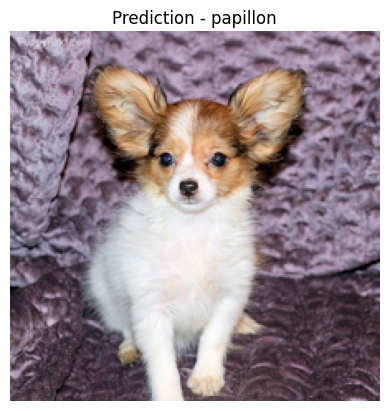

In [47]:
make_prediction('papilion.jpg', is_web_link=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Maltese_dog - 99.99%
Japanese_spaniel - 0.01%
Chihuahua - 0.00%
papillon - 0.00%
Shih_Tzu - 0.00%


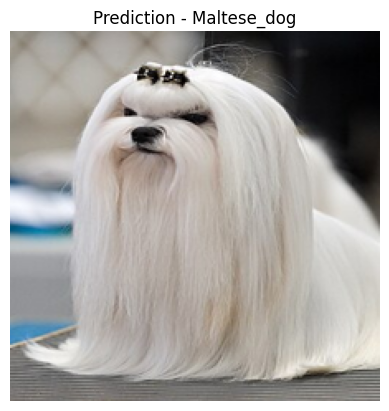

In [51]:
make_prediction('1AKC_Maltese_Dog_Show_2011.jpg',is_web_link=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
Shih_Tzu - 99.74%
Pekinese - 0.25%
Maltese_dog - 0.00%
Blenheim_spaniel - 0.00%
Rhodesian_ridgeback - 0.00%


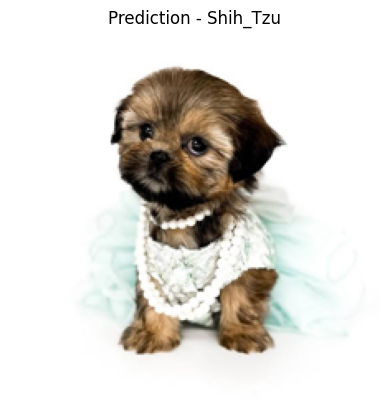

In [52]:
make_prediction('shihtzu.jpg',is_web_link=False)